In [1]:
import pandas as pd 
import numpy as np
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. EDA
In this part, we will

In [2]:
root_dir = "../data/"
returns = pd.read_csv(root_dir + "returns.csv")
geography = pd.read_csv(root_dir + "geography.csv")
inventory = pd.read_csv(root_dir + "inventory.csv")
order_items = pd.read_csv(root_dir + "order_items.csv")
orders = pd.read_csv(root_dir + "orders.csv")
payments = pd.read_csv(root_dir + "payments.csv")
products = pd.read_csv(root_dir + "products.csv")
promotions = pd.read_csv(root_dir + "promotions.csv")
reviews = pd.read_csv(root_dir + "reviews.csv")
sales = pd.read_csv(root_dir + "sales.csv", parse_dates=["Date"])
sample_submission = pd.read_csv(root_dir + "sample_submission.csv")
shipments = pd.read_csv(root_dir + "shipments.csv")
web_traffic = pd.read_csv(root_dir + "web_traffic.csv")
customers = pd.read_csv(root_dir + "customers.csv")


/tmp/ipykernel_14955/2648743432.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(root_dir + "order_items.csv")


In [3]:
target_prediction = sales[['Revenue', 'COGS']]

- The target prediction is revenue and cost of good sold
- We will do many trial and errors between different features so we can examine what is the most relevant features to target prediction

### Revenue performance

In [47]:
# Does revenue increase or decrease overtime

/tmp/ipykernel_179546/2815342065.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  avgRev = sales.set_index("Date").resample("M").mean()


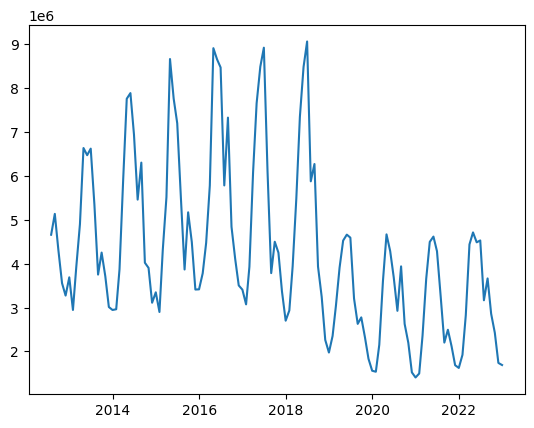

In [64]:
avgRev = sales.set_index("Date").resample("M").mean()
plt.plot(avgRev.index, avgRev["Revenue"])

- Doanh số bán hàng tăng trong 5 năm từ năm 2013 đến năm 2018, rồi giảm dần từ năm 2018 đến cuối năm 2022
- Tại sao doanh số bán hàng lại giảm

In [50]:
rev_ana = order_items[["order_id", "quantity", "unit_price"]]
rev_ana["revenue"] = rev_ana["quantity"] * rev_ana["unit_price"]
# rev_ana = merge(orders[["custo    mer_id", "order_id"]], on="order_id")
rev_ana = rev_ana.groupby("order_id")["revenue"].sum().to_frame().reset_index()
rev_ana = orders[["order_date", "order_id", "customer_id"]].merge(rev_ana, on="order_id")
rev_ana["order_date"] = pd.to_datetime(rev_ana["order_date"])

rev_ana["year"] = rev_ana["order_date"].dt.year

analysis = rev_ana.groupby("year").agg(
    revenue=("revenue", "sum"),
    orders=("order_id", "nunique"),
    customers=("customer_id", "nunique")
)

analysis["avg_order_value"] = analysis["revenue"] / analysis["orders"]
analysis["orders_per_customer"] = analysis["orders"] / analysis["customers"]

/tmp/ipykernel_14955/1537467387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rev_ana["revenue"] = rev_ana["quantity"] * rev_ana["unit_price"]


In [74]:
analysis

,revenue,orders,customers,avg_order_value,orders_per_customer
year,,,,,
2012,7.414977e+08,32051,22068,23134.933326,1.452374
2013,1.657169e+09,76849,39384,21563.968526,1.951275
2014,1.871846e+09,80645,40376,23210.935369,1.997350
2015,1.889934e+09,82622,40807,22874.462334,2.024702
2016,2.104641e+09,82247,40933,25589.269852,2.009308
2017,1.911164e+09,76010,39651,25143.590650,1.916976
2018,1.850122e+09,69510,37922,26616.637262,1.832973
2019,1.136801e+09,41601,27312,27326.300846,1.523177
2020,1.054512e+09,34881,24335,30231.706625,1.433368


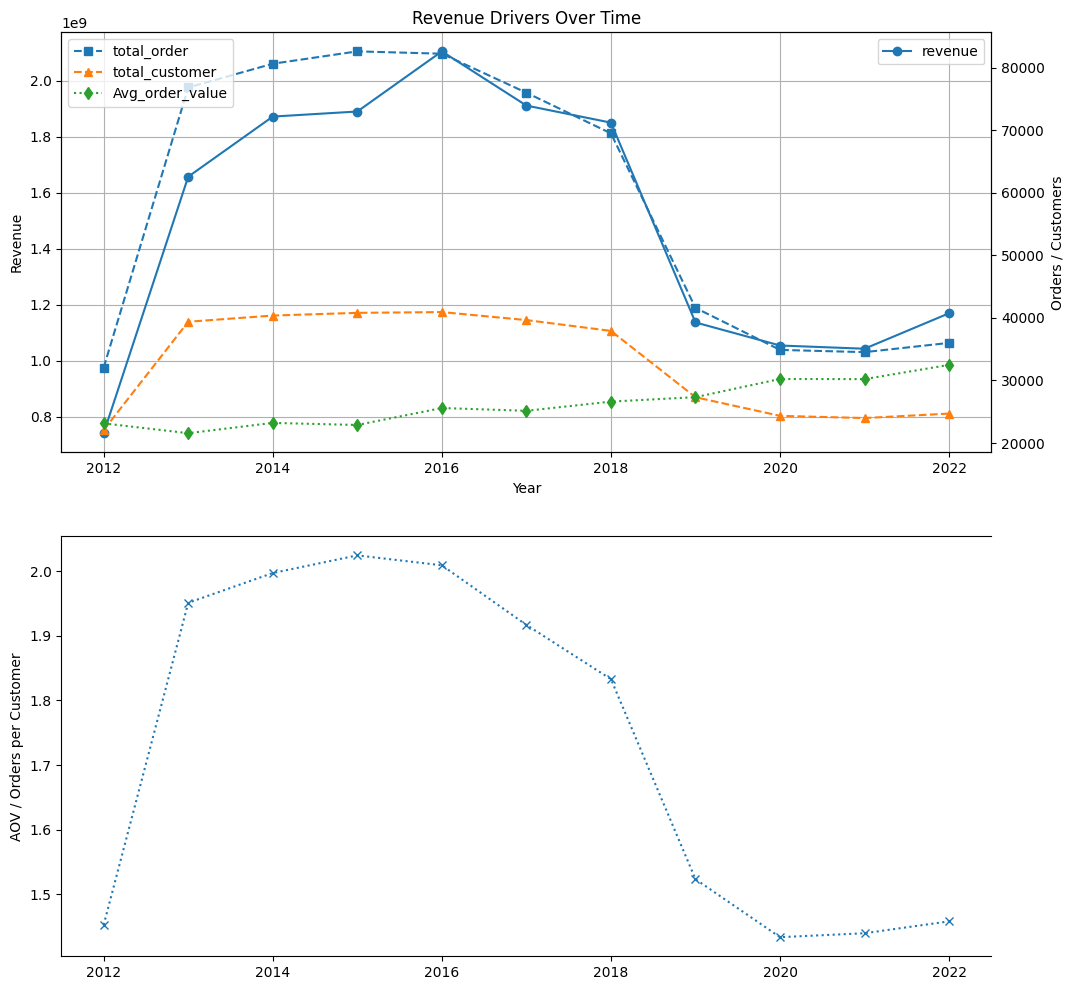

In [77]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(2, 1, figsize=(12, 12))

# Revenue (primary axis)
ax1[0].plot(analysis.index, analysis["revenue"], marker='o', label="revenue")
ax1[0].set_xlabel("Year")
ax1[0].set_ylabel("Revenue")

# Second axis (orders & customers)
ax2 = ax1[0].twinx()
ax2.plot(analysis.index, analysis["orders"], linestyle='--', marker='s', label="total_order")
ax2.plot(analysis.index, analysis["customers"], linestyle='--', marker='^', label="total_customer")
ax2.set_ylabel("Orders / Customers")

# Third axis (AOV & frequency)
ax3 = ax1[1]
ax3.spines["right"].set_position(("outward", 60))  # shift axis
ax2.plot(analysis.index, analysis["avg_order_value"], linestyle=':', marker='d', label="Avg_order_value")
ax3.plot(analysis.index, analysis["orders_per_customer"], linestyle=':', marker='x')
ax3.set_ylabel("AOV / Orders per Customer")

# Title & grid
plt.title("Revenue Drivers Over Time")
ax1[0].legend()
ax2.legend(loc="upper left")
# plt.legend()
ax1[0].grid()

plt.show()

- Để phân tích về sự sụt giảm của revenue chúng ta cần cân nhắc hai yếu tố số lượng đơn hàng và giá trị trung bình mỗi đơn hàng với công thức: 
- $$revenue\ =\ số\ lượng\ đơn\ hàng\ \times giá\ trị\ trung\ bình\ mỗi\ đơn\ hàng$$
  + Giá trị trung bình đơn hàng không đổi thậm chí còn tăng (đường màu xanh lá cây)
  + Trong khi số lượng đơn hàng giảm kỉ lục trong năm 2019

- Sự sụt giảm về số lượng đơn hàng do hai yếu tố:
    + Sự sụt giảm về số lượng khách hàng
    + Sự sụt giảm về số lượng đơn hàng của mỗi khách hàng 

In [37]:
orders

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign
...,...,...,...,...,...,...,...,...
646940,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign
646941,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral
646942,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign
646943,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct


- User acquisition analysis

In [81]:
order_items["revenue"] = order_items["quantity"] * order_items["unit_price"]
channel_analysis = order_items.groupby("order_id")["revenue"].sum().to_frame().reset_index()
channel_analysis = channel_analysis.merge(orders, on="order_id")
channel_analysis.sort_values(by="order_date", inplace=True)


first_orders = (
    channel_analysis.groupby("customer_id")
    .first()
    .reset_index()
)

first_orders["year"] = pd.to_datetime(first_orders["order_date"]).dt.year

acquisition = (
    first_orders
    .groupby(["year", "order_source"])
    .size()
    .reset_index(name="new_customers")
)

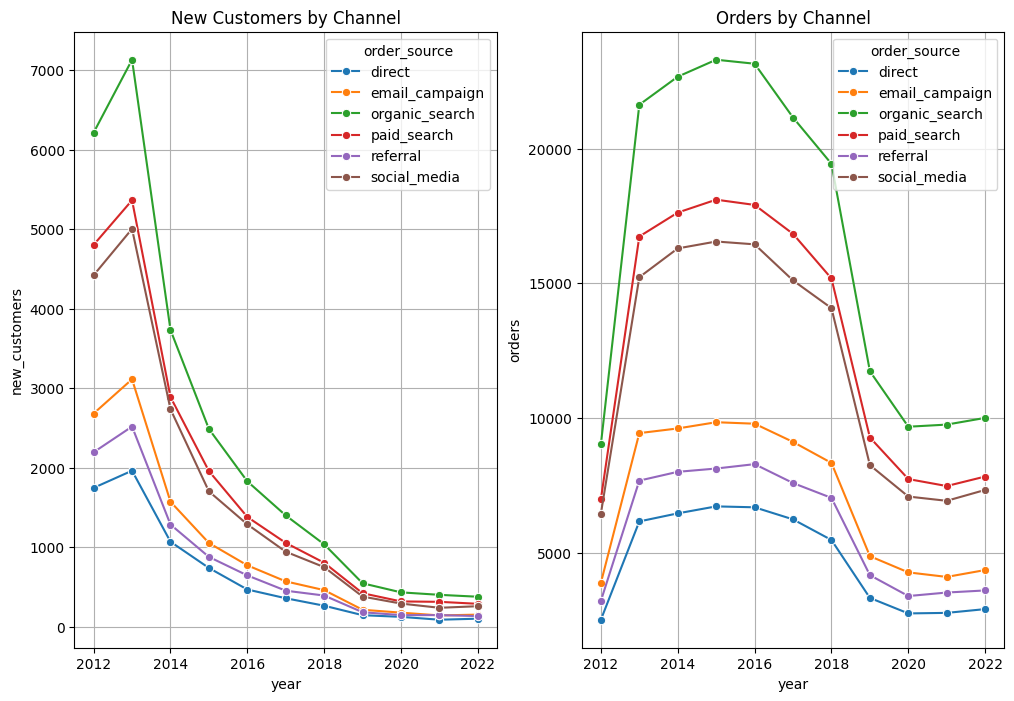

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 8))


sns.lineplot(data=acquisition, x="year", y="new_customers", hue="order_source", marker="o", ax=axes[0])
axes[0].set_title("New Customers by Channel")
axes[0].grid()

channel_analysis["year"] = pd.to_datetime(channel_analysis["order_date"]).dt.year
orders_channel = (
    channel_analysis.groupby(["year", "order_source"])["order_id"]
    .count()
    .reset_index(name="orders")
)
sns.lineplot(data=orders_channel, x="year", y="orders", hue="order_source", marker="o", ax=axes[1])
axes[1].set_title("Orders by Channel")
axes[1].grid()
plt.show()

- Gần như không có quá nhiều user mới kể từ trước Covid => new user acquisition không cao.
- Đặc điểm của hầu hết các customer là organic search, tức chỉ khi khách hàng có nhu cầu muốn mua mới tìm đến sản phẩm.
- Sản phẩm không được biết đến nhiều bằng các chương trình campaign ví dụ như email campaign.

=> Khả năng thu hút tệp khách hàng mới không hiệu quả + khách hàng chỉ mua khi thực sự có nhu cầu (business quá thụ động trong việc tiệp cận với customer)


- Phân tích theo channel

- Không có sự chuyển dịch giữa các kênh khác nhau doanh thu tăng và giảm đều giữa các kênh

<Axes: xlabel='year', ylabel='sessions'>

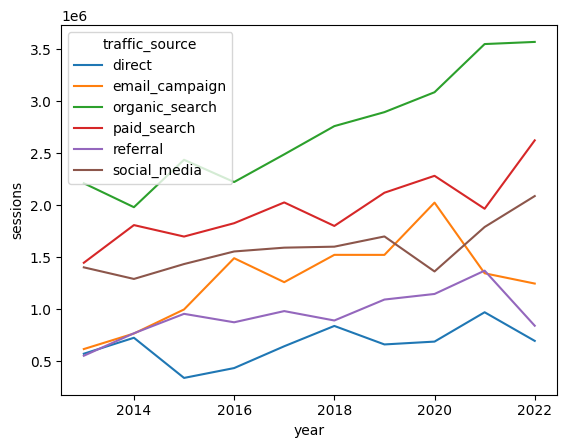

In [128]:
web_traffic["year"] = pd.to_datetime(web_traffic["date"]).dt.year

traffic_trend = (
    web_traffic.groupby(["year", "traffic_source"])["sessions"]
    .sum()
    .reset_index()
)
sns.lineplot(data=traffic_trend, x="year", y="sessions", hue="traffic_source")

- Tại sao traffic tăng nhưng order lại giảm

<Axes: xlabel='year', ylabel='bounce_rate'>

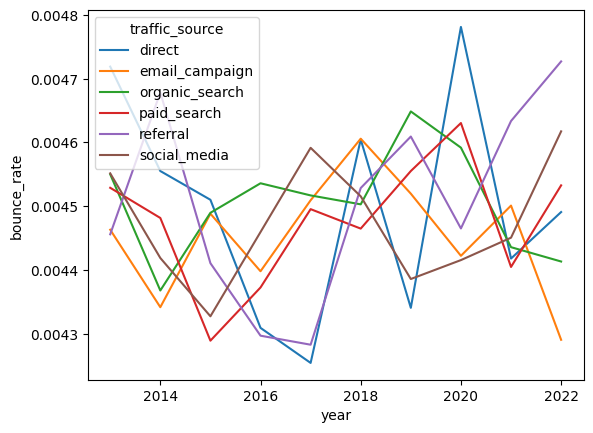

In [138]:
bounce_rate = web_traffic.groupby(by=['year', 'traffic_source'])['bounce_rate'].mean().to_frame().reset_index()
sns.lineplot(data=bounce_rate, x="year", y="bounce_rate", hue="traffic_source")

<Axes: xlabel='year', ylabel='cv_rate'>

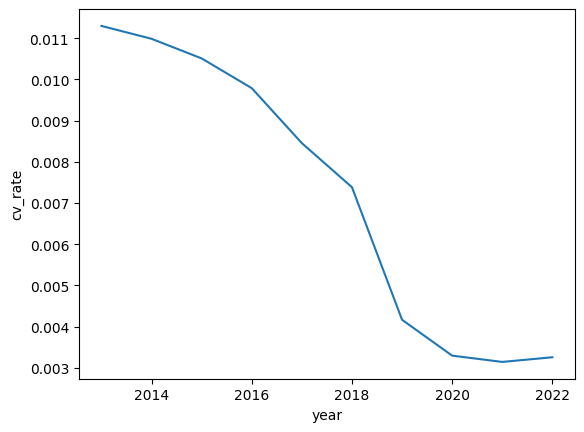

In [163]:
cv = web_traffic.groupby('year')['sessions'].sum().to_frame()
orders['year'] = pd.to_datetime(orders['order_date']).dt.year
orders_cv = orders.groupby("year")['order_id'].count()
cv['orders'] = orders_cv[1:]
cv['cv_rate'] = cv['orders'] / cv['sessions']
cv.reset_index()
sns.lineplot(data=cv, x="year", y='cv_rate')

Conversion rate giảm trong khi traffic tăng,
đặc biệt từ organic search.
Điều này cho thấy traffic quality hoặc user intent không phù hợp,
cần phân tích sâu hơn theo channel và engagement metrics.

## Retention

In [122]:
channel_analysis["order_date"] = pd.to_datetime(channel_analysis["order_date"])
retention = channel_analysis.sort_values("order_date")

# Cohort = first purchase
retention["cohort"] = retention.groupby("customer_id")["order_date"].transform("min").dt.to_period("Y")

# Order year
retention["order_year"] = retention["order_date"].dt.to_period("Y")

In [123]:
cohort_data = (
    retention.groupby(["cohort", "order_year"])["customer_id"]
    .nunique()
    .reset_index()
)

# cohort size
cohort_size = cohort_data[cohort_data["cohort"] == cohort_data["order_year"]]
cohort_size = cohort_size.set_index("cohort")["customer_id"]

# merge + calculate retention
cohort_data["cohort_size"] = cohort_data["cohort"].map(cohort_size)
cohort_data["retention_rate"] = cohort_data["customer_id"] / cohort_data["cohort_size"]

In [126]:
cohort_data

,cohort,order_year,customer_id,cohort_size,retention_rate
0,2012,2012,22068,22068,1.000000
1,2012,2013,14285,22068,0.647317
2,2012,2014,14345,22068,0.650036
3,2012,2015,14482,22068,0.656244
4,2012,2016,14551,22068,0.659371
...,...,...,...,...,...
61,2020,2021,102,1500,0.068000
62,2020,2022,107,1500,0.071333
63,2021,2021,1340,1340,1.000000
64,2021,2022,90,1340,0.067164


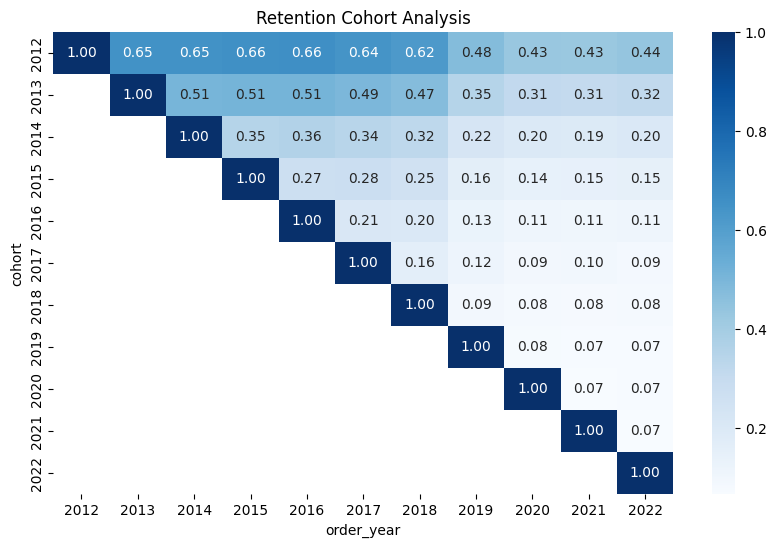

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = cohort_data.pivot(index="cohort", columns="order_year", values="retention_rate")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Retention Cohort Analysis")
plt.show()